# Análisis Geoespacial IPM - Zona de Estudio: Barrio Obrero

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en el polígono de Barrio Obrero.

**Características:**
- Mapa base con manzanas catastrales de fondo (contexto territorial).
- Polígono del área de estudio destacado.
- Etiquetas de valores dentro de cada manzana.
- Paleta de colores accesible para personas daltónicas (cividis).
- Leyenda de categorías semánticas basada en la incidencia.
- Celda de descarga del GeoJSON.

In [23]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn -q

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [25]:
# 2. Clonar o actualizar repositorio (solo Colab)
import sys
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    print('Repositorio listo')

# 3. Definir rutas base
DATA_BASE = '../data' if os.path.exists('../data') else os.path.join(REPO_DIR, 'indice_Pobreza/data')

# Capa principal: manzanas IPM con variables (zona de estudio)
PATH_IPM_VARS = os.path.join(DATA_BASE, 'IPM_GEO/geojson_filtrado_poligono_Barrio_Obrero/Mzn_ipm_filtrado_poligono_Barrio_Obrero.geojson')
# Capa de fondo: manzanas catastrales de Cali
PATH_MANZANAS_FONDO = os.path.join(DATA_BASE, 'geojson_Manzanas_catastrales/geojson_Manzanas_catastrales.geojson')
# Polígono del área de estudio (Barrio Obrero - nueva área)
PATH_AREA_ESTUDIO = os.path.join(DATA_BASE, 'Geojson_Barrio_Obrero/Geojson_Barrio_Obrero_cambioArea.geojson')

# Cargar capas
gdf = gpd.read_file(PATH_IPM_VARS)
gdf_fondo = gpd.read_file(PATH_MANZANAS_FONDO)
gdf_area = gpd.read_file(PATH_AREA_ESTUDIO)

# Unificar todo a WGS84 (EPSG:4326)
CRS_WGS84 = 'EPSG:4326'
gdf = gdf.to_crs(CRS_WGS84)
gdf_fondo = gdf_fondo.to_crs(CRS_WGS84)
gdf_area = gdf_area.to_crs(CRS_WGS84)

print(f'Datos cargados: {len(gdf)} manzanas en zona de estudio')
print(f'Fondo: {len(gdf_fondo)} manzanas de contexto')
print(f'Área de estudio: {len(gdf_area)} polígonos')
print(f'CRS unificado: {gdf.crs}')

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 128.46 KiB | 2.57 MiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   5996d10..9df7520  main       -> origin/main
Updating 5996d10..9df7520
Fast-forward
 .../notebooks_py/05_mapeo_ipm_barrio_obrero.ipynb  | 167 +++++++--------------
 1 file changed, 58 insertions(+), 109 deletions(-)
Repositorio listo
Datos cargados: 16 manzanas en zona de estudio
Fondo: 15291 manzanas de contexto
Área de estudio: 1 polígonos
CRS unificado: EPSG:4326


In [26]:
# 3. Identificación de las 15 variables y selección de las Top 5
variables_ipm = [
    'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_',
    'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_',
    'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_'
]

# Diccionario para nombres legibles
diccionario_nombres = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo Logro Educativo', 'INFANCIA_': 'Barreras Infancia',
    'INASIS_': 'Inasistencia Escolar', 'REZAGO_': 'Rezago Escolar', 'TRAB_INFAN': 'Trabajo Infantil',
    'DEPEN_': 'Dependencia Económica', 'INFOR_': 'Informalidad', 'SALUD_': 'Sin Aseguramiento Salud',
    'ASEGU_': 'Barreras Salud', 'HACI_': 'Hacinamiento Crítico', 'PARED_': 'Paredes Inadecuadas',
    'EXCRE_': 'Excretas Inadecuadas', 'PISOS_': 'Pisos Inadecuados', 'AGUA_': 'Sin Agua Mejorada'
}

# Calcular promedio local para elegir las 5 más relevantes (mayor incidencia)
top_5 = gdf[variables_ipm].mean().sort_values(ascending=False).head(5).index.tolist()
print('Las 5 variables con mayor incidencia en Barrio Obrero son:')
for v in top_5:
    print(f'- {diccionario_nombres[v]} ({v})')

Las 5 variables con mayor incidencia en Barrio Obrero son:
- Informalidad (INFOR_)
- Bajo Logro Educativo (BAJO_)
- Dependencia Económica (DEPEN_)
- Rezago Escolar (REZAGO_)
- Barreras Salud (ASEGU_)


In [27]:
# 4. Función de mapeo con escala semántica accesible (daltonismo)
from matplotlib.patheffects import withStroke
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import numpy as np
import re

# Escala semántica (8 categorías de intensidad)
CATEGORIAS = [
    'Bajo', 'Moderado-Bajo', 'Moderado', 'Moderado-Alto',
    'Alto', 'Muy Alto', 'Extremo', 'Extremo Máximo'
]

# Paleta accesible para daltonismo: cividis discretizado en 8 niveles
_cividis = plt.get_cmap('cividis', 8)
COLORES_ACCESIBLES = [_cividis(i) for i in range(8)]

# Proporciones de corte para escalar al ref_max de cada indicador
PROPORCIONES_CORTE = [0.0, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.24, 1.0]

# ref_max por variable (del contexto metodológico)
REF_MAX_VARS = {
    'INFOR_': 100, 'BAJO_': 80, 'DEPEN_': 80, 'REZAGO_': 60, 'ASEGU_': 50,
    'SALUD_': 40, 'ANALF_': 40, 'HACI_': 40, 'INASIS_': 30, 'INFANCIA_': 30,
    'AGUA_': 20, 'TRAB_INFAN': 20, 'EXCRE_': 20, 'PARED_': 20, 'PISOS_': 20
}

def get_boundaries(column):
    """Calcula los límites de categoría escalados al ref_max del indicador."""
    ref_max = REF_MAX_VARS.get(column, 100)
    return [p * ref_max for p in PROPORCIONES_CORTE]

def limpiar_titulo(titulo):
    """Elimina texto entre paréntesis relacionado con paletas/accesibilidad."""
    return re.sub(r'\s*\([^)]*(?:paleta|accesible|daltonismo|cividis)[^)]*\)', '', titulo, flags=re.IGNORECASE).strip()

def plot_ipm_variable(gdf, gdf_fondo, gdf_area, column, title, zona_nombre='Barrio Obrero'):
    """Genera mapa con fondo de manzanas, polígono de área de estudio y datos IPM."""
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))
    
    # --- Definir extent basado en el área de estudio + margen ---
    bounds = gdf_area.total_bounds  # [minx, miny, maxx, maxy]
    rango_x = bounds[2] - bounds[0]
    rango_y = bounds[3] - bounds[1]
    margen_x = rango_x * 0.3
    margen_y = rango_y * 0.3
    extent = [bounds[0] - margen_x, bounds[1] - margen_y, bounds[2] + margen_x, bounds[3] + margen_y]
    
    # Fijar extent ANTES de plotear capas
    ax.set_xlim(extent[0], extent[2])
    ax.set_ylim(extent[1], extent[3])
    ax.set_aspect('equal')
    
    # --- Capa 1: Fondo de manzanas (toda la hoja, gris muy claro) ---
    # Se plotea sin restringir por el extent para que llene todo el lienzo disponible
    gdf_fondo.plot(ax=ax, facecolor='#F8F8F8', edgecolor='#DCDCDC', linewidth=0.2, alpha=0.8, zorder=1)
    
    # --- Capa 2: Polígono del área de estudio (destacado) ---
    gdf_area.plot(ax=ax, facecolor='none', edgecolor='#E63946', linewidth=2.5, linestyle='--', zorder=2)
    
    # --- Capa 3: Manzanas con datos IPM (escala semántica) ---
    boundaries = get_boundaries(column)
    cmap = ListedColormap(COLORES_ACCESIBLES)
    norm = BoundaryNorm(boundaries, cmap.N)
    
    gdf.plot(column=column,
             cmap=cmap,
             norm=norm,
             edgecolor='black',
             linewidth=0.6,
             alpha=0.95,
             ax=ax,
             zorder=3)
    
    # --- Etiquetas de valor dentro de cada manzana ---
    for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):
        txt_color = 'white' if label > 0 else 'black'
        stroke_color = 'black' if label > 0 else 'white'
        ax.annotate(f'{label:.1f}',
                    xy=(x, y),
                    xytext=(0, 0),
                    textcoords='offset points',
                    ha='center',
                    fontsize=8,
                    fontweight='bold',
                    color=txt_color,
                    path_effects=[withStroke(linewidth=2, foreground=stroke_color)],
                    zorder=4)
    
    # --- Leyenda (a la derecha, encima de las manzanas) ---
    legend_patches = []
    for i, cat in enumerate(CATEGORIAS):
        rango_min = boundaries[i]
        rango_max = boundaries[i + 1]
        label = f'{rango_min:.1f}% - {rango_max:.1f}% | {cat}'
        legend_patches.append(mpatches.Patch(color=COLORES_ACCESIBLES[i], label=label))
    legend_patches.append(mpatches.Patch(facecolor='none', edgecolor='#E63946', linewidth=2, linestyle='--', label='Área de estudio'))
    
    ax.legend(handles=legend_patches,
              title=f'% Hogares con {title}',
              loc='center left',
              bbox_to_anchor=(1.02, 0.5),
              fontsize=9,
              title_fontsize=10,
              framealpha=0.92,
              edgecolor='gray',
              borderaxespad=0)
    
    # --- Título limpio, centrado y separado del borde ---
    titulo = limpiar_titulo(f'Incidencia de {title} - {zona_nombre}')
    fig.suptitle(titulo, fontsize=14, fontweight='bold', y=0.92)
    
    # Restaurar extent (por si geopandas lo modificó)
    ax.set_xlim(extent[0], extent[2])
    ax.set_ylim(extent[1], extent[3])
    ax.set_axis_off()
    plt.tight_layout(rect=[0, 0, 0.75, 0.90])
    plt.show()

/tmp/ipykernel_25933/2059139559.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


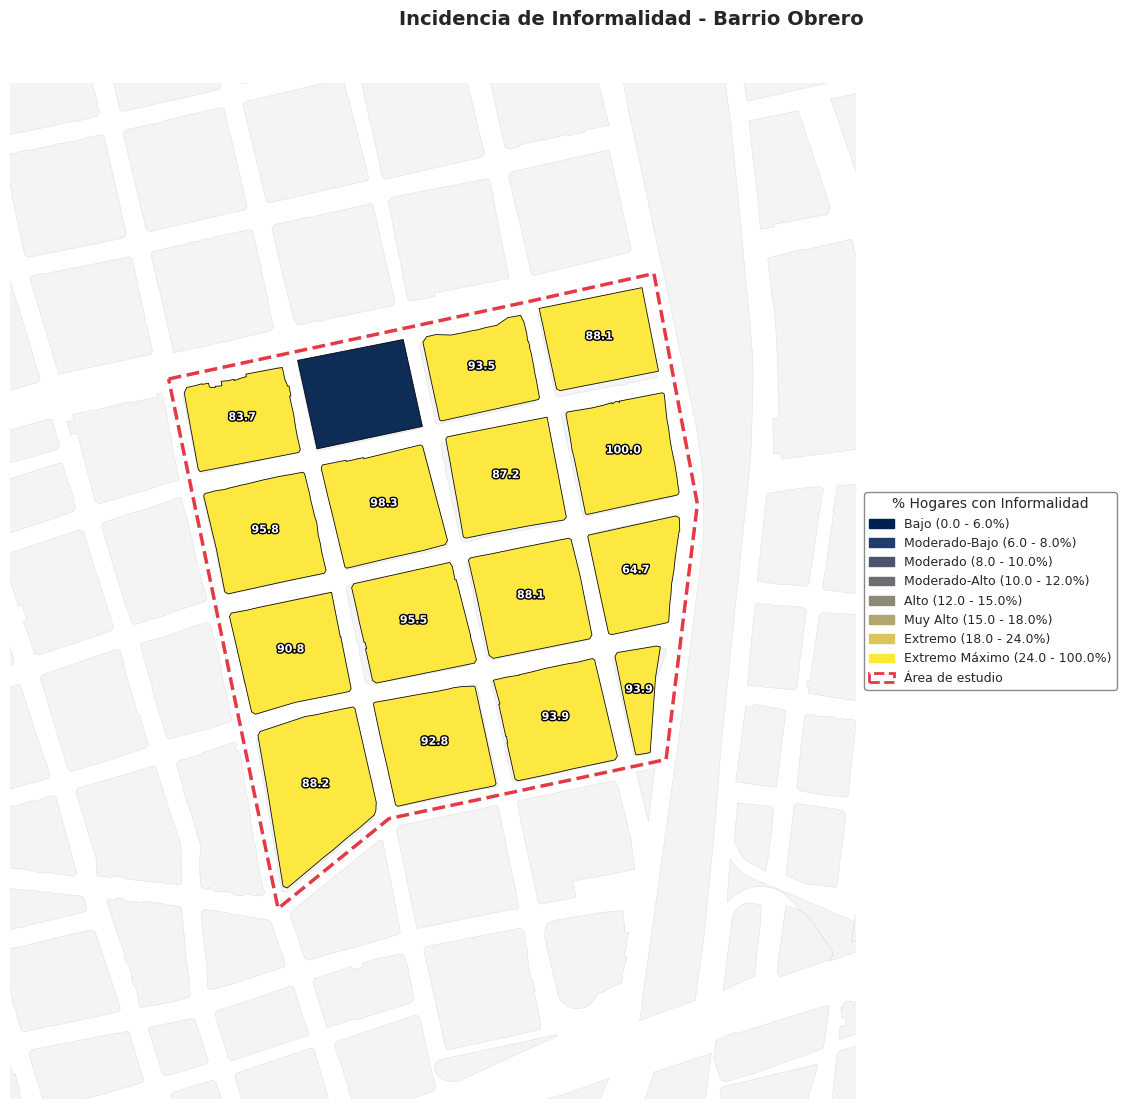

/tmp/ipykernel_25933/2059139559.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


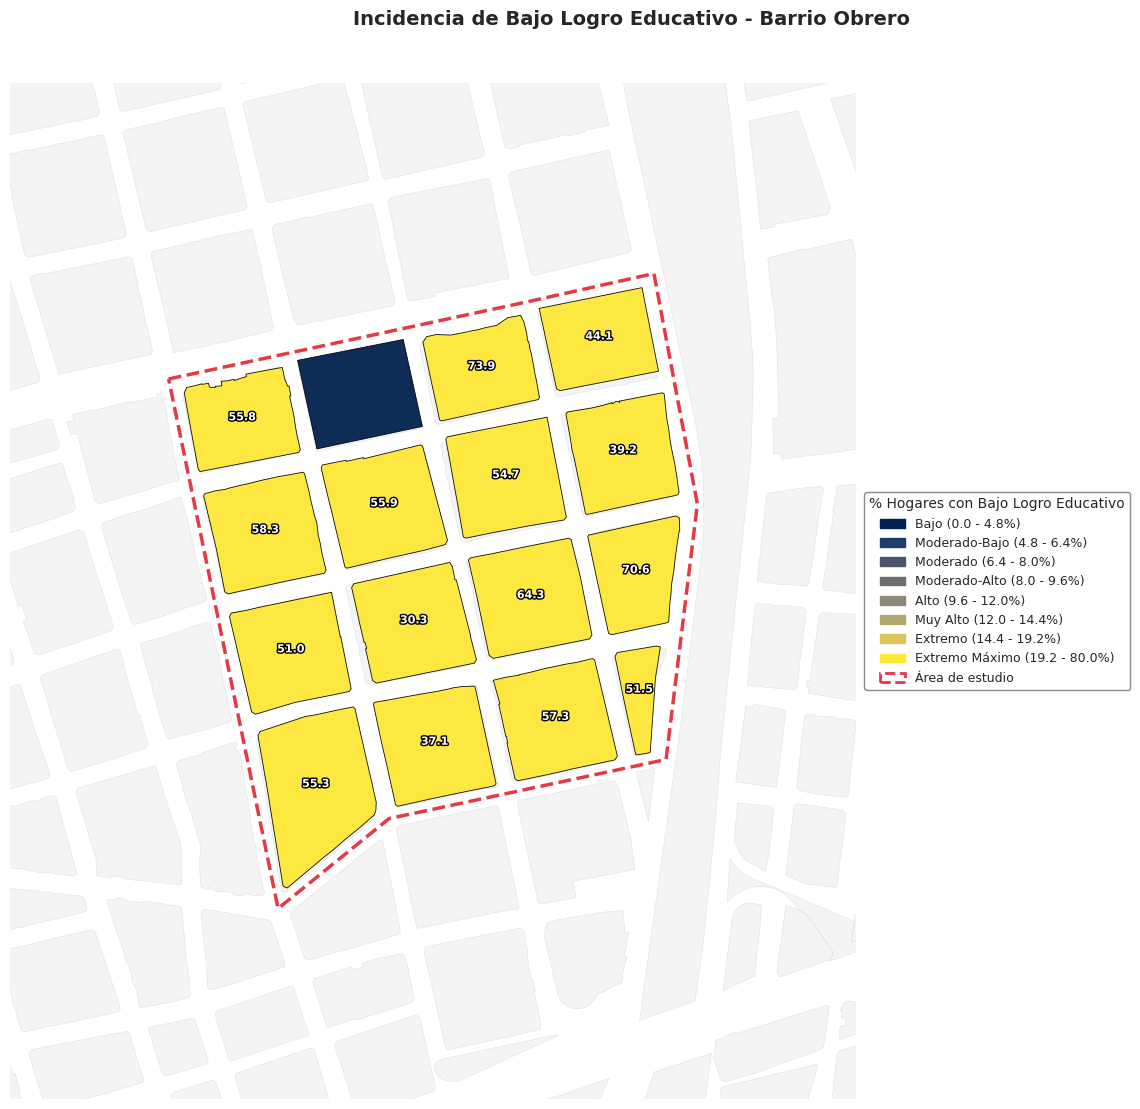

/tmp/ipykernel_25933/2059139559.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


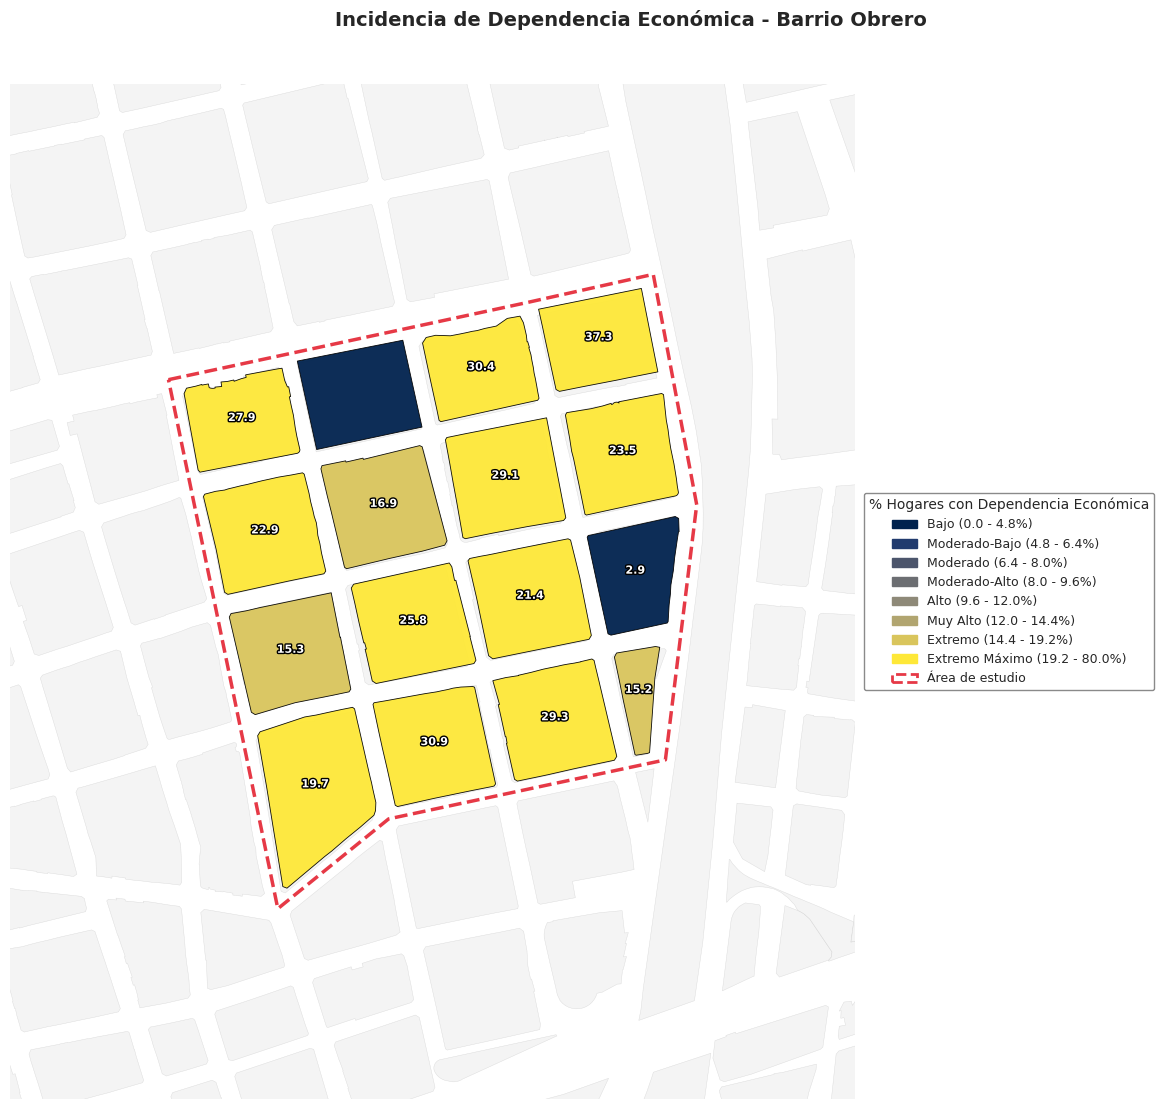

/tmp/ipykernel_25933/2059139559.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


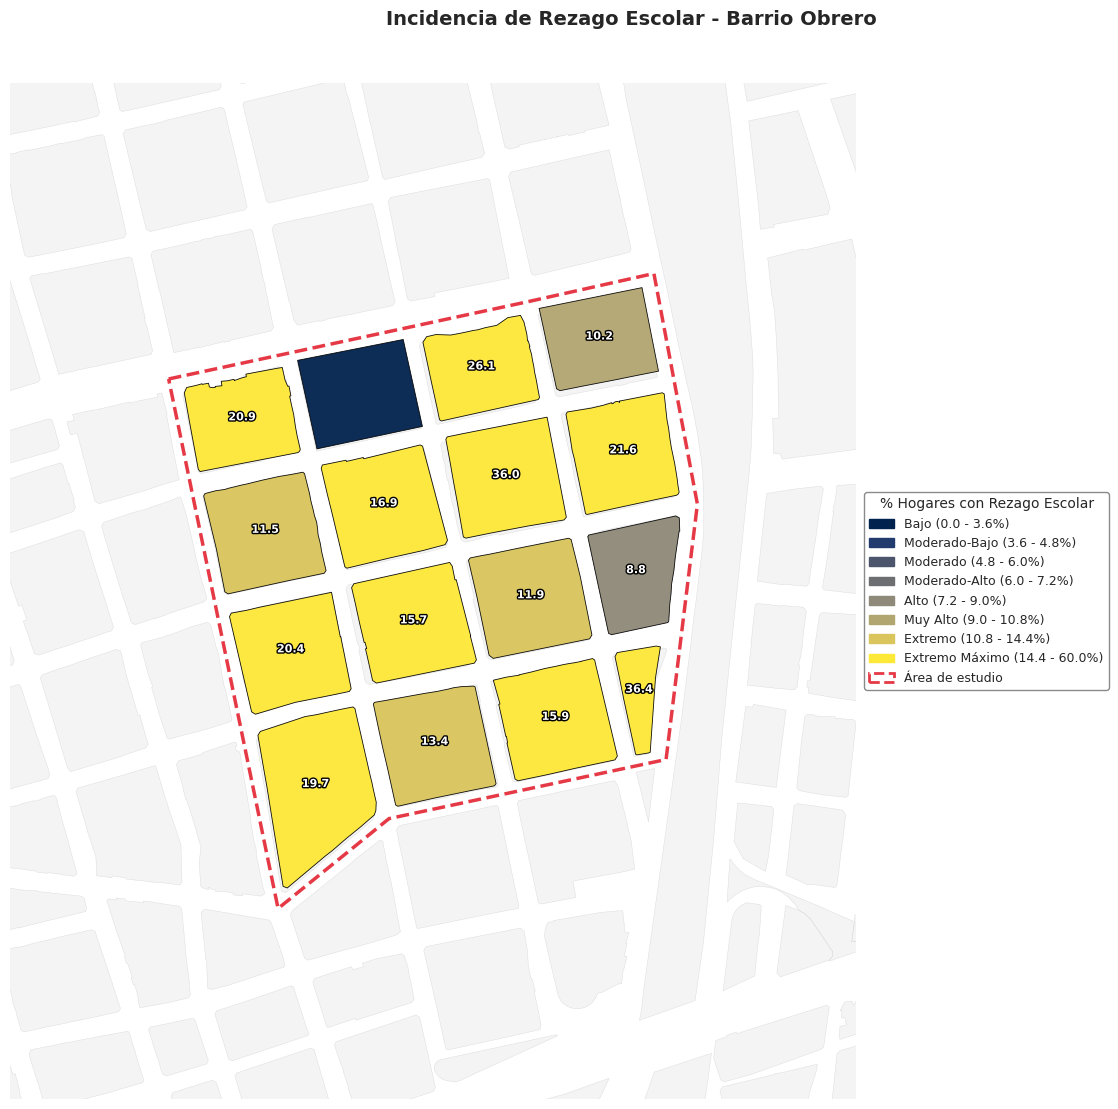

/tmp/ipykernel_25933/2059139559.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


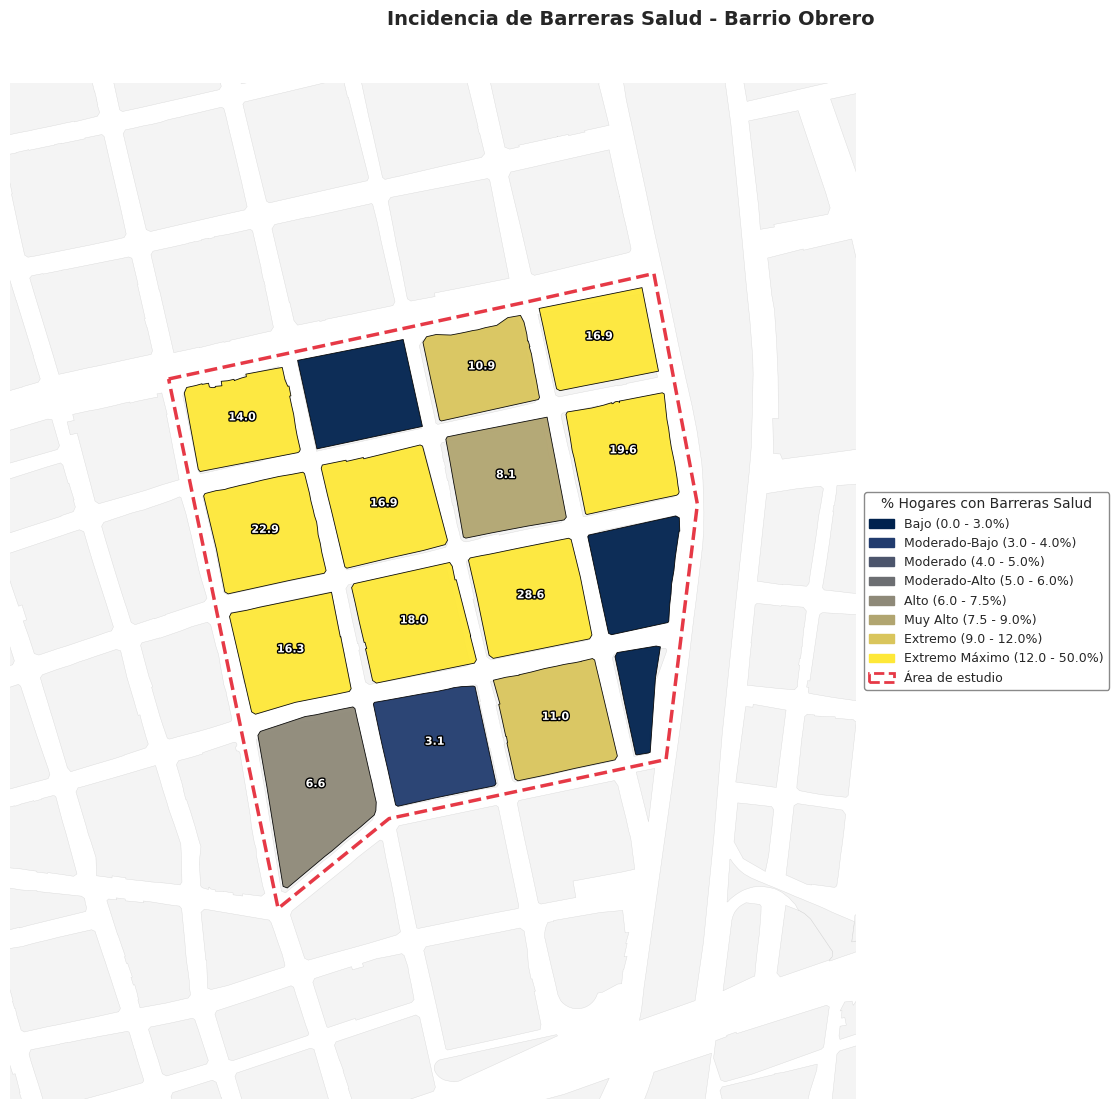

In [28]:
# 5. Generar los 5 mapas prioritarios
for var in top_5:
    plot_ipm_variable(gdf, gdf_fondo, gdf_area, var, diccionario_nombres[var], 'Barrio Obrero')

In [29]:
# 6. Descargar GeoJSON a tu PC (solo funciona en Google Colab)
import sys
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(PATH_IPM_VARS)
    print('Descarga iniciada: Mzn_ipm_variables_filtrado_poligono_Barrio_Obrero.geojson')
else:
    print(f'Archivo disponible en: {PATH_IPM_VARS}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada: Mzn_ipm_variables_filtrado_poligono_Barrio_Obrero.geojson
